## Plot selected event summary figures
### Figs 5-8, figures for gifs

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from matplotlib import rcParams
import matplotlib

In [2]:
rcParams['font.size'] = 20

In [3]:
#output file location
output_write = '/div/nac/users/zofias/XXN/extreme_loc_tables'
out_plots = '/div/nac/users/zofias/plots/XXN/paper_plots'
input_fileloc = '/div/no-backup-nac/users/zofias/CESM2-LENS/weather_data/paper_selected_events_24_06_26'

group_label = '24_06_26_paper_events'

var_name='PRECT'

sigma_lab = 6

# %%
# select region by changing region_label
region_label = 'NO_ext' #sys.argv[3] #'EU' # 'SA' 'EA' 'NA' 'EU'

regions = {'SA': [5,35,65,95],
           'EA' : [20,53,95,133],
           'NA' : [25,70,-150,-45],
           'EU' : [35,70,-10,45],
           'NO' : [53,72,0,32],
           'NO_ext': [50,75,-15,32]}

#selects lat lon bounds for region
lat_min, lat_max, lon_min, lon_max = regions[region_label]


In [4]:
locs_dataframe = pd.read_csv(f'/div/nac/users/zofias/XXN/extreme_loc_tables/paper_selected_events_table_24_06_26.csv',index_col=0)

In [5]:
nrows = math.ceil((locs_dataframe.shape[0]/3))
nevents = locs_dataframe.shape[0]

In [6]:
#make dictionary of dataframes loaded in - single files for each location
datasets = {}

for a, b in enumerate(locs_dataframe.index):
    print(f'Processing {a+1} of {len(locs_dataframe.index)}')
    import_data = xr.open_mfdataset(f"{input_fileloc}/*{locs_dataframe['member_lab'][a]}*{locs_dataframe['decade_lab'][a]}", decode_times=True)
    #reset lon coord
    import_data = import_data.assign_coords(lon=(((import_data.lon + 180) % 360) - 180)).sortby('lon')
    #select region
    import_data = import_data#.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
    #add to dictionary
    datasets[a] = import_data

Processing 1 of 4


/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/div

Processing 2 of 4
Processing 3 of 4


/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/div

Processing 4 of 4


/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/div

### Plot precip event day

In [7]:
fig_labels = ['Trøndelag','Northern Norway', 'Southern Norway', 'Western Norway']
fig_labs = ['Trøndelag','Northern_Norway', 'Southern_Norway', 'Western_Norway']

In [8]:
#Find max value for gridbox precip for each event
for n,time in enumerate(locs_dataframe.date):
    print((datasets[n][var_name]*8.64e7).sel(time=time).max().values)

339.84268
306.74344
144.24785
123.857864


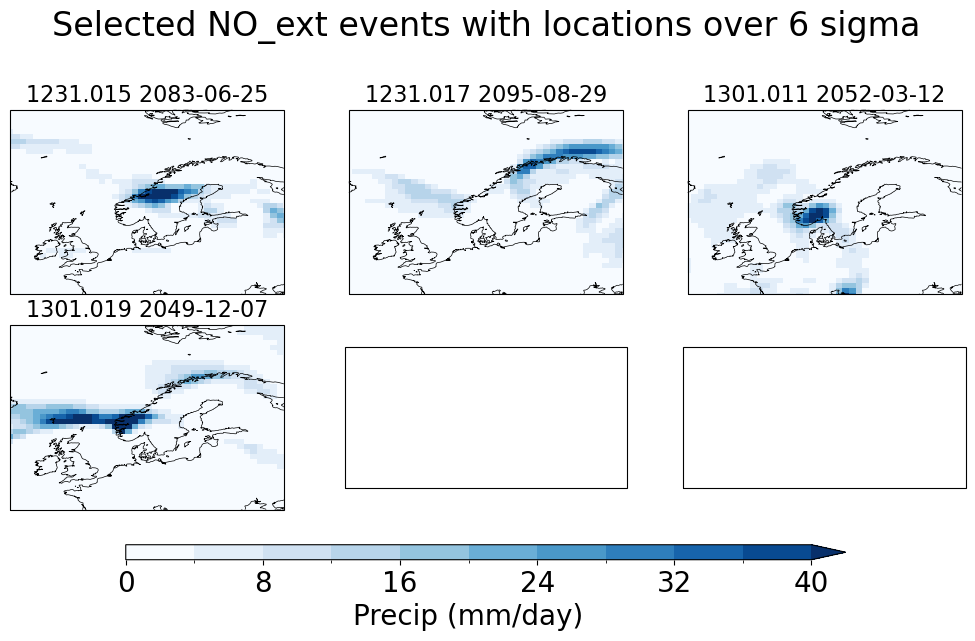

In [9]:
# Precip plot for each event, day of event
fig, axs = plt.subplots(nrows=nrows,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,5*nrows)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()#Loop over all of the models

for n,time in enumerate(locs_dataframe.date):
    member_lab = locs_dataframe.member_lab[n]
    #exp_lab = locs_dataframe.exp[n]
    #suite_lab= locs_dataframe.suiteid[n]
    #lon_lab=events_array.lon[n]

    #circle2 = plt.Circle((lon_lab, lat_lab), 2, color='blue', fill=False)

    fg = (datasets[n][var_name]*8.64e7).sel(time=time).plot(ax=axs[n],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=40, vmin=0, 
        #cbar_kwargs={'label': f'Temperature (K)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max+5),
        ylim=(lat_min-5,lat_max+5),
        )
    
    #axs[n].add_patch(circle2)
    axs[n].set_title(f'{member_lab} {time}',fontsize=16)
    axs[n].coastlines(linewidth=0.5)  # cartopy function

cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

plt.suptitle(f'Selected {region_label} events with locations over {sigma_lab} sigma',y=1.0)
fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
#fig.savefig(f'{out_plots}{region_label}_select_events_precip_maps.pdf', format='pdf', bbox_inches='tight')

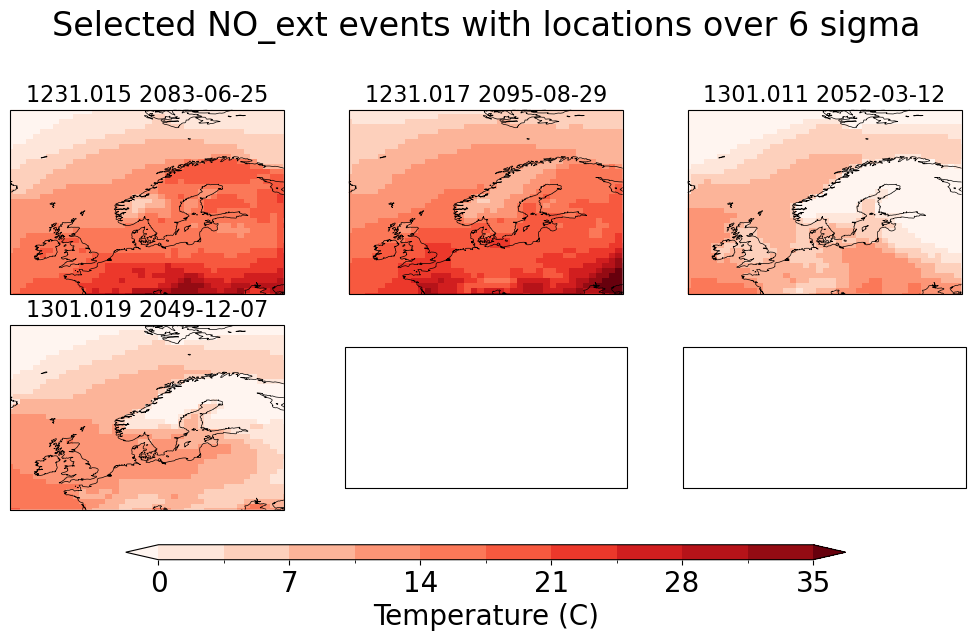

In [10]:
# Temperature plot for each event
fig, axs = plt.subplots(nrows=nrows,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,5*nrows)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()#Loop over all of the models

for n,time in enumerate(locs_dataframe.date):
    member_lab = locs_dataframe.member_lab[n]
    #exp_lab = locs_dataframe.exp[n]
    #suite_lab= locs_dataframe.suiteid[n]
    #lon_lab=events_array.lon[n]

    #circle2 = plt.Circle((lon_lab, lat_lab), 2, color='blue', fill=False)

    fg = (datasets[n]['TS']-273.15).sel(time=time).plot(ax=axs[n],cmap='Reds',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=35, vmin=0, 
        #cbar_kwargs={'label': f'Temperature (K)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max+5),
        ylim=(lat_min-5,lat_max+5),
        )
    
    #axs[n].add_patch(circle2)
    axs[n].set_title(f'{member_lab} {time}',fontsize=16)
    axs[n].coastlines(linewidth=0.5)  # cartopy function

cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Temperature (C)')

plt.suptitle(f'Selected {region_label} events with locations over {sigma_lab} sigma',y=1.0)
fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
#fig.savefig(f'{out_plots}{region_label}_select_events_precip_maps.pdf', format='pdf', bbox_inches='tight')

In [12]:
#set lats and lons for plotting
lats=datasets[0].lat
lons=datasets[0].lon

In [ ]:
for n,time in enumerate(locs_dataframe.date):
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=2,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(14,8),
                        layout='constrained'
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()#Loop over all of the models

    
    member_lab = locs_dataframe.member_lab[n]
    lon_lab = locs_dataframe.lon[n]
    lat_lab= locs_dataframe.lat[n]
    time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]

    circle0 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle1 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle3 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle4 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle5 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    
    u = datasets[n].isel(time=time_ind).U850
    v = datasets[n].isel(time=time_ind).V850
    wind_speed = np.sqrt(u**2 + v**2)



    fg0 = (datasets[n][var_name]*8.64e7).isel(time=slice(time_ind-1,time_ind+1)).sum(dim='time').plot(ax=axs[0],cmap='Blues',levels=11,#,norm=norm, #
                                                vmax=120, vmin=0, 
        #cbar_kwargs={'label': f'5 day precip (mm/day)','orientation':'horizontal','pad':0.05},
        add_colorbar=False,
        xlim=(lon_min,lon_max+5),
        ylim=(lat_min-5,lat_max+5),
        )
    
    axs[0].add_patch(circle0)
    #axs[n].set_title(f'{fig_labels[n]} {time}')
    axs[0].coastlines(linewidth=0.5)  # cartopy function

    fig.colorbar(fg0, ax=axs[0], orientation='horizontal', pad=0.05, label='5 day precip (mm/day)')

    fg_psl = (datasets[n]['PSL'].sel(lon=slice(lon_min-1,lon_max+6),lat=slice(lat_min-6,lat_max+6)).isel(time=time_ind)/100).plot.contour(ax=axs[1],
                                                             #cmap='viridis',
                                                             #add_colorbar=False,
                                                             vmax=1020, vmin=980,
                                                             levels=9,#
                                                             xlim=(lon_min,lon_max+5),
                                                             ylim=(lat_min-5,lat_max+5),
                                                             colors='k',
                                                             linewidths=0.7
                                                             )
    fg1 = wind_speed.plot.contourf(ax=axs[1],cmap='summer_r',levels=11, vmin=0,vmax=50,
                                   add_colorbar=False,
                                   #cbar_kwargs={'label': f'Wind speed (m/s)','extend':'both','ticks': np.arange(0, 51, 10),'orientation':'horizontal','pad':0.05,'extend':'max'}
                                   )
    
    axs[1].add_patch(circle1)
    axs[1].set_title(f'{fig_labels[n]} event {time}')
    axs[1].coastlines(linewidth=0.5)  # cartopy function
    axs[1].add_patch(circle1)
    axs[1].clabel(fg_psl,fontsize=7)

    fig.colorbar(fg1, ax=axs[1], orientation='horizontal', pad=0.05, label='Wind speed (m/s)',
                 extend='max', ticks=np.arange(0, 51, 10))


    fg2 = axs[2].quiver(lons, lats, u.squeeze(), v.squeeze(), scale=500)

    #axs[2].set_title(f"{member_lab} {time}",fontsize=16)
    axs[2].coastlines(linewidth=0.5)  # cartopy function
    axs[2].set_xlim(lon_min,lon_max+5)
    axs[2].set_ylim(lat_min-5,lat_max+5)
    axs[2].add_patch(circle2)






    fg3 = (datasets[n][var_name]*8.64e7).isel(time=time_ind-1).plot(ax=axs[3],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=40, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max+5),
        ylim=(lat_min-5,lat_max+5),
        )
    
    axs[3].add_patch(circle3)
    axs[3].set_title(f'-1 day')
    axs[3].coastlines(linewidth=0.5)  # cartopy function


    fg4 = (datasets[n][var_name]*8.64e7).isel(time=time_ind).plot(ax=axs[4],cmap='Blues',levels=11,#,norm=norm, #
                                                vmax=40, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        add_colorbar=False,
        xlim=(lon_min,lon_max+5),
        ylim=(lat_min-5,lat_max+5),
        )
    
    axs[4].add_patch(circle4)
    axs[4].set_title(f'{time}')
    axs[4].coastlines(linewidth=0.5)  # cartopy function

    fig.colorbar(fg4, ax=axs[4], orientation='horizontal', pad=0.05, label='Precip (mm/day)')

    fg = (datasets[n][var_name]*8.64e7).isel(time=time_ind+1).plot(ax=axs[5],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=40, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max+5),
        ylim=(lat_min-5,lat_max+5),
        )
    
    axs[5].add_patch(circle5)
    axs[5].set_title(f'+1 day')
    axs[5].coastlines(linewidth=0.5)  # cartopy function

    #plt.suptitle(f'{fig_labels[n]} event {time}',y=0.96)

    for ax in [axs[2], axs[3], axs[5]]:
        dummy = fig.colorbar(fg4, ax=ax, orientation='horizontal', pad=0.05)
        dummy.ax.set_visible(False)

    fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.1, wspace=0.1)
    #fig.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
    fig.savefig(f'{out_plots}/{fig_labs[n]}_event_summary.pdf', format='pdf')

In [ ]:
#plot for making gifs from 2 weeks before up to 3 days after event
for n,time in enumerate(locs_dataframe.date):
    #loop over 15 times
    for index,day in enumerate(range(-15,3)): #(-15,3)
        #Define the figure and each axis for the 3 rows and 3 columns
        fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,10)
                       )
        # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
        axs=axs.flatten()#Loop over all of the models

    
        member_lab = locs_dataframe.member_lab[n]
        lon_lab = locs_dataframe.lon[n]
        lat_lab= locs_dataframe.lat[n]
        time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]

        circle0 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        circle1 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        circle3 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)

        fg = (datasets[n][var_name]*8.64e7).isel(time=time_ind+day).plot(ax=axs[0],cmap='Blues',levels=9,#,norm=norm, #
                                                vmax=40, vmin=0, 
            cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,'extend':'max'},
            xlim=(lon_min,lon_max),
            ylim=(lat_min,lat_max),
            )
        axs[0].set_title(f'{time}',fontsize=16)
        axs[0].coastlines(linewidth=0.5)  # cartopy function
        axs[0].add_patch(circle0)


        u = datasets[n].isel(time=time_ind+day).U850
        v = datasets[n].isel(time=time_ind+day).V850
        wind_speed = np.sqrt(u**2 + v**2)

    
        fg = (datasets[n]['PSL'].sel(lon=slice(lon_min-1,lon_max+1),lat=slice(lat_min-1,lat_max+1)).isel(time=time_ind+day)/100).plot.contour(ax=axs[1],
                                                             vmax=1020, vmin=980,
                                                             levels=9,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             colors='k',
                                                             linewidths=0.7
                                                              )
        fg2 = wind_speed.plot.contourf(ax=axs[1],cmap='summer_r',levels=10, 
                                                            vmin=10,vmax=100,
                                                            cbar_kwargs={'label': f'Wind speed (m/s)','extend':'both','ticks': np.arange(10, 101, 20),'orientation':'horizontal','pad':0.05,'extend':'max'})
    
        axs[1].set_title(f'{time}',fontsize=16)
        axs[1].coastlines(linewidth=0.5)  # cartopy function
        axs[1].add_patch(circle1)
        axs[1].clabel(fg,fontsize=7)


        fg = (datasets[n]['TS'].isel(time=time_ind+day)-273.15).plot(ax=axs[2],
                                                             cmap='Reds',
                                                             vmax=35, vmin=-10,
                                                             levels=25,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             cbar_kwargs={'label': f'Temperature (C)','extend':'both','ticks': np.arange(-10, 36, 5),'orientation':'horizontal','pad':0.05},
                                                              )
    
        #axs[n].add_patch(circle2)
        axs[2].set_title(f"{time}",fontsize=16)
        axs[2].coastlines(linewidth=0.5)  # cartopy function
        axs[2].add_patch(circle2)


    
    

        u = datasets[n].isel(time=time_ind+day).U850.squeeze()
        v = datasets[n].isel(time=time_ind+day).V850.squeeze()

        fg = axs[3].quiver(lons, lats, u, v, scale=1000)

        axs[3].set_title(f"{time}",fontsize=16)
        axs[3].coastlines(linewidth=0.5)  # cartopy function
        axs[3].set_xlim(lon_min,lon_max)
        axs[3].set_ylim(lat_min,lat_max)
        axs[3].add_patch(circle3)

        plt.suptitle(f'{fig_labels[n]} event {time}: {day} days',y=0.9,fontsize=18)
        fig.savefig(f'{out_plots}/gif_plots/{str(index).zfill(2)}_{region_label}_{group_label}_{member_lab}_all_maps_{n}_paper.png', format='png', bbox_inches='tight')
        plt.close()

#cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

#plt.suptitle(f'Selected {region_label} events with locations over {sigma_lab} sigma',y=0.96)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
#fig.savefig(f'{out_plots}{region_label}_select_events_precip_maps.pdf', format='pdf', bbox_inches='tight')

## Sigma levels used for selecting events

In [ ]:
#monthly dataset map
sigma_levs = xr.open_dataset('/div/nac/users/zofias/XXN/extreme_loc_tables/NO_BSSP370smbb_PRECT_climo_sigma6.nc')

In [6]:
sigma_levs

<xarray.Dataset>
Dimensions:      (lat: 20, lon: 26, month: 12)
Coordinates:
  * lat          (lat) float64 53.25 54.19 55.13 56.07 ... 69.27 70.21 71.15
  * lon          (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 27.5 28.75 30.0 31.25
  * month        (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    rx5day       (month, lat, lon) float32 ...
    std_monthly  (month, lat, lon) float32 ...
    sigma_level  (month, lat, lon) float32 ...

Text(0.5, 0.99, 'standard deviation')

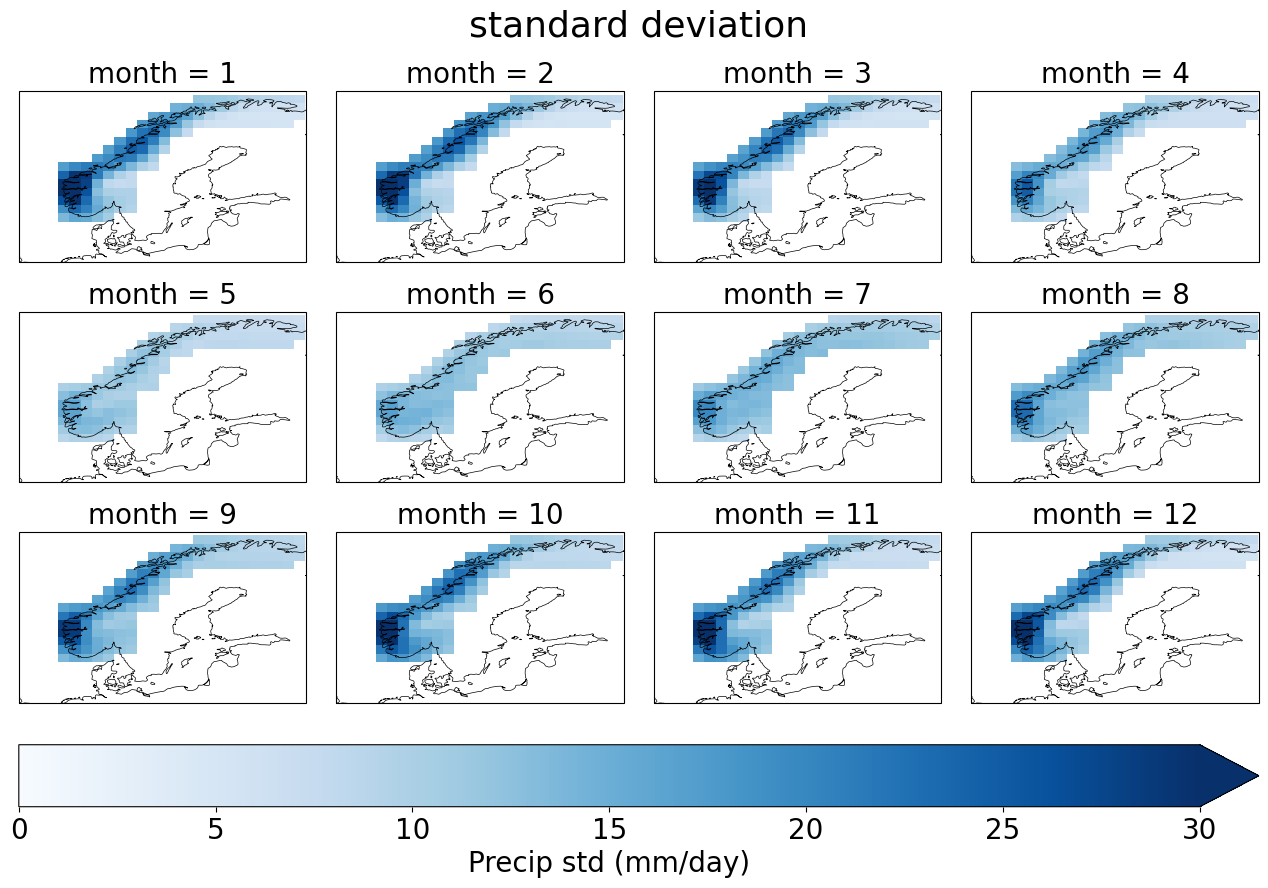

In [31]:
#Plot event on ERA5 native resolution
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = sigma_levs['std_monthly'].plot(cmap='Blues',
                                                       vmin=0,vmax=30,
                                                       col='month',
                                                       col_wrap=4,
    transform=ccrs.PlateCarree(),  # remember to provide this!
    subplot_kws={"projection": ccrs.PlateCarree()},
    cbar_kwargs={'label': f'Precip std (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(0,32),
    ylim=(53,72),
    )

fg.map(lambda: plt.gca().coastlines(linewidth=0.5))
fg.fig.suptitle('standard deviation',y=0.99,fontsize=26)

Text(0.5, 0.99, 'sigma level used for event identification')

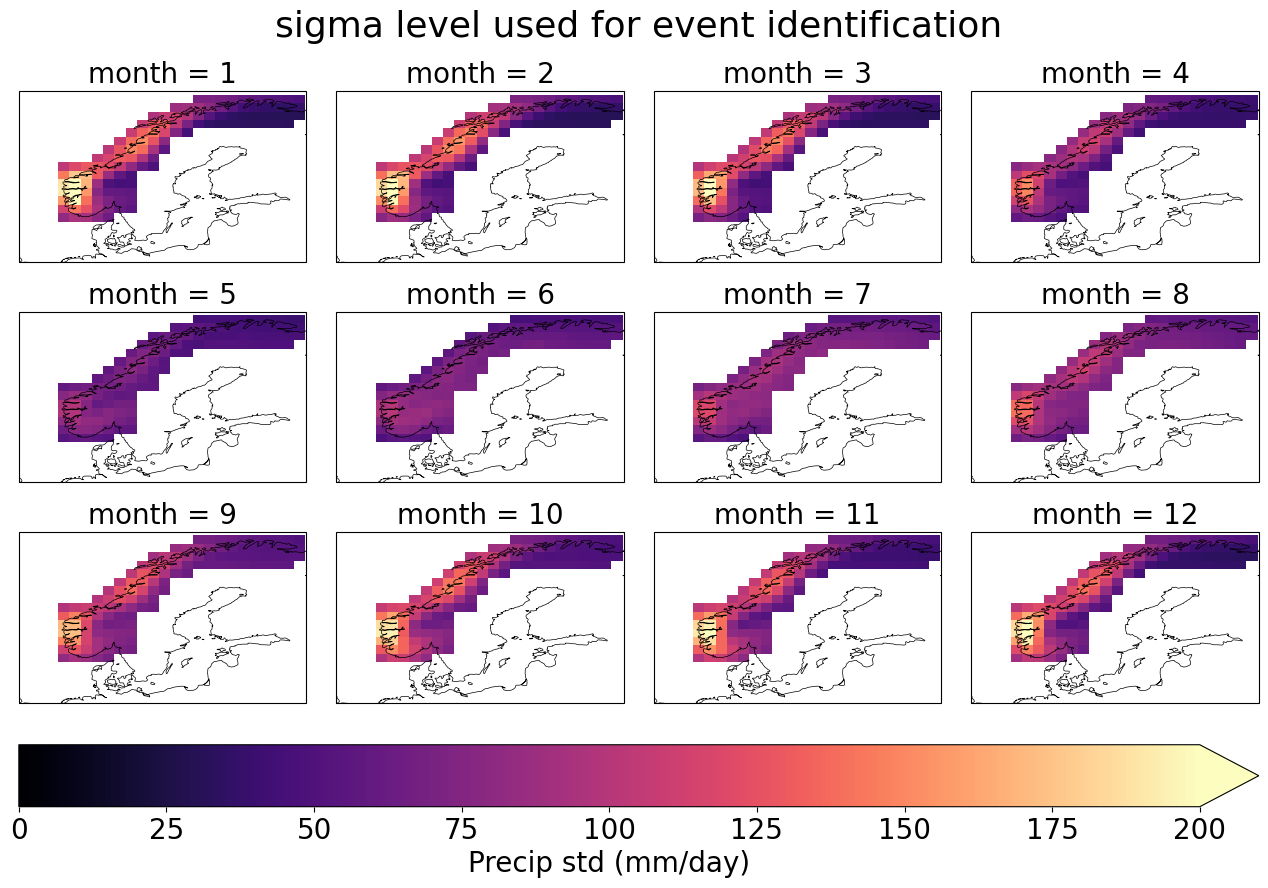

In [30]:
#Plot event on ERA5 native resolution
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = sigma_levs['sigma_level'].plot(cmap='magma',
                                                       vmin=0,vmax=200,
                                                       col='month',
                                                       col_wrap=4,
    transform=ccrs.PlateCarree(),  # remember to provide this!
    subplot_kws={"projection": ccrs.PlateCarree()},
    cbar_kwargs={'label': f'Precip std (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(0,32),
    ylim=(53,72),
    )

fg.map(lambda: plt.gca().coastlines(linewidth=0.5))
fg.fig.suptitle('sigma level used for event identification',y=0.99,fontsize=26)